In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import io
import datetime
import timeit
import os



from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# data source: Tiger Data (TimescaleDB on Tiger Cloud) when TIGER_URL is in .env, otherwise the local CSVs
# tables are loaded by tiger/load_tiger.py and keep the CSV names and columns
load_dotenv()
tigerUrl = os.getenv("TIGER_URL")
engine = create_engine(tigerUrl.replace("postgres://", "postgresql+psycopg://", 1)) if tigerUrl else None

def load(table):
    if engine is None:
        return pd.read_csv(f"data/{table}.csv", na_values="Not Applicable")
    return pd.read_sql(f"SELECT * FROM {table} ORDER BY 1", engine)

stuCur = load("students_current")
stuExp = load("student_experience")
stuAlum = load("alumni")



In [2]:
# Table: summary of each experience type 
catbyType = stuExp.groupby("experience_type").agg(
  records=("record_id","count"),
  students=("campus_id","nunique"),
  orgs=("organization","nunique"),
  avg_terms=("duration_terms","mean"),
  avg_hours=("hours_per_week", "mean"),
  pct_paid=("is_paid", lambda s: s.dropna().astype(bool).mean() * 100),
).round(1).sort_values("records", ascending=False)
catbyType

,records,students,orgs,avg_terms,avg_hours,pct_paid
experience_type,,,,,,
Student Organization,4176,3208,1,3.1,4.0,0.0
Internship,4106,3012,58,1.0,28.4,87.0
Hackathon,3259,1489,8,1.0,36.3,0.0
Certification,2845,1712,17,1.0,NaN,NaN
Campus Job,2080,2080,7,3.3,13.0,100.0
Undergraduate Research,954,954,7,2.4,10.2,63.7
Tutoring,715,715,4,2.5,7.1,100.0
Competitive Team,700,700,1,2.0,8.7,0.0
Co-op,678,652,58,2.0,40.0,89.4


In [3]:
# Chart: % of current students who have done each experience type at least once
expCur = stuExp[stuExp["campus_id"].isin(stuCur["campus_id"])]
pctCur = expCur.groupby("experience_type")["campus_id"].nunique() / len(stuCur) * 100









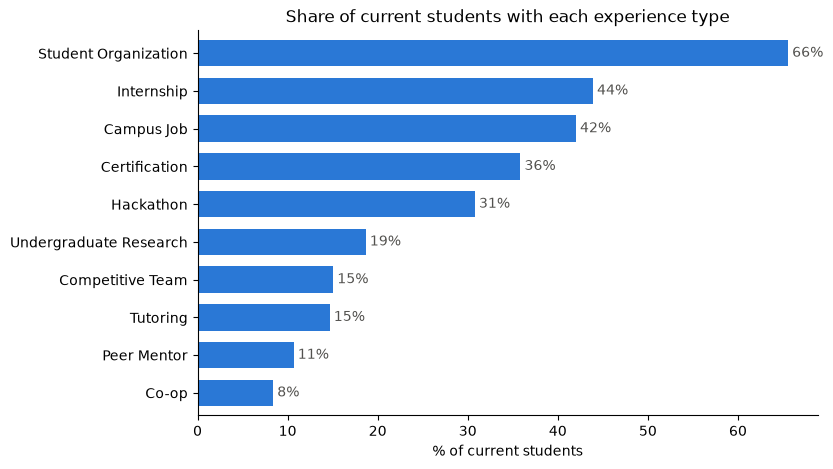

In [4]:

ax = pctCur.sort_values().plot.barh(color="#2a78d6", figsize=(8, 5), width=0.7)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color="#52514e")
ax.set(xlabel="% of current students", ylabel="", title="Share of current students with each experience type")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


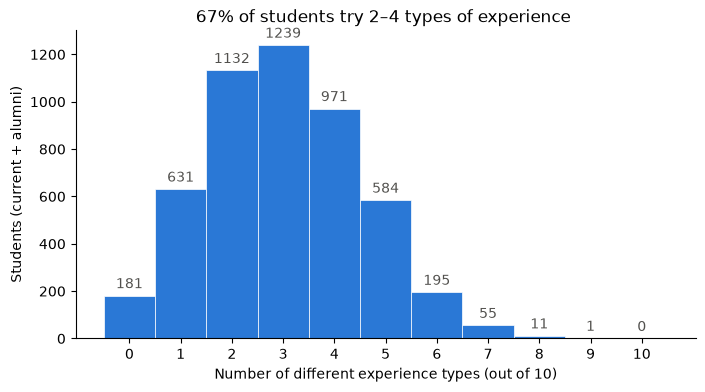

In [5]:
# Chart: histogram of how many different experience types each person tried (current + alumni)
# breadth = distinct experience types per person; people with no experience rows count as 0
ids = pd.concat([stuCur["campus_id"], stuAlum["campus_id"]])
breadth = stuExp.groupby("campus_id")["experience_type"].nunique().reindex(ids, fill_value=0)
share = breadth.between(2, 4).mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(breadth, bins=np.arange(-0.5, 11.5), color="#2a78d6", edgecolor="white", linewidth=0.5)
ax.bar_label(ax.containers[0], fmt="%d", padding=3, color="#52514e")
ax.set(xticks=range(11),
       xlabel="Number of different experience types (out of 10)", ylabel="Students (current + alumni)",
       title=f"{share:.0f}% of students try 2–4 types of experience ")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

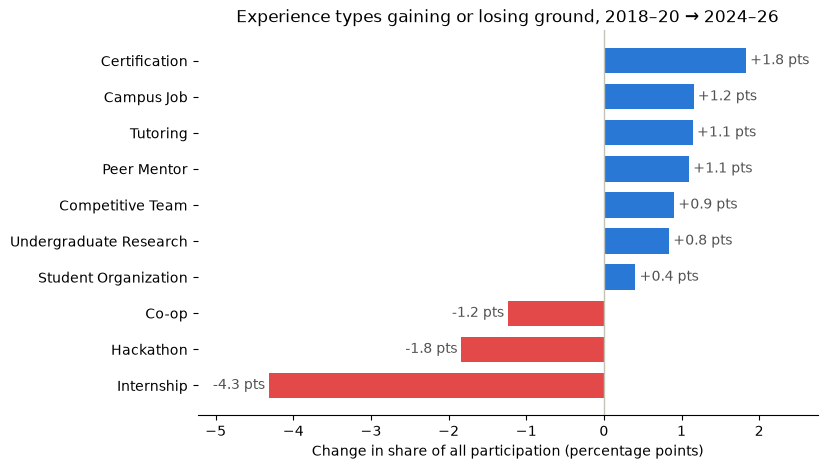

In [6]:
# Chart: change in each experience type's share of all participation, 2018–20 → 2024–26, diverging bar
# share, not raw counts: current students make recent years busier for every type
year = stuExp["term"].str[-4:].astype(int)
period = pd.cut(year, [2017, 2020, 2023, 2026], labels=["2018–20", "2021–23", "2024–26"])
typeJoins = pd.DataFrame({"type": stuExp["experience_type"], "period": period, "campus_id": stuExp["campus_id"]}).drop_duplicates()
typeShare = pd.crosstab(typeJoins["type"], typeJoins["period"], normalize="columns") * 100
typeChange = (typeShare["2024–26"] - typeShare["2018–20"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(typeChange.index, typeChange, color=["#2a78d6" if v > 0 else "#e34948" for v in typeChange], height=0.7)
ax.bar_label(ax.containers[0], labels=[f"{v:+.1f} pts" for v in typeChange], padding=3, color="#52514e")
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.margins(x=0.15)
ax.set(xlabel="Change in share of all participation (percentage points)",
       title="Experience types gaining or losing ground, 2018–20 → 2024–26")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

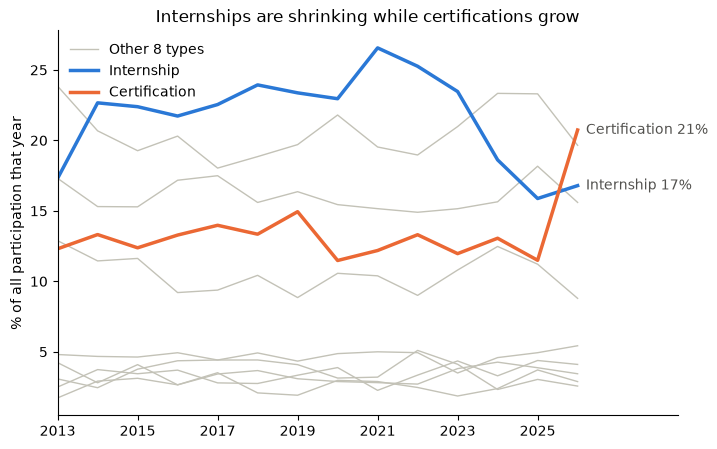

In [7]:
# Chart: share of all participation by experience type per year, from the continuous aggregate experience_yearly (line chart)
# the aggregate is pre-computed inside Tiger Data, so this reads a few hundred summary rows instead of every activity row
yearly = pd.read_sql("""
    SELECT extract(year FROM year)::int AS year, experience_type, sum(records) AS records
    FROM experience_yearly WHERE year >= '2013-01-01'
    GROUP BY 1, 2""", engine)
shareByYear = yearly.pivot(index="year", columns="experience_type", values="records")
shareByYear = shareByYear.div(shareByYear.sum(axis=1), axis=0) * 100
highlight = {"Internship": "#2a78d6", "Certification": "#eb6834"}

fig, ax = plt.subplots(figsize=(8, 5))
for i, t in enumerate(shareByYear.columns.drop(list(highlight))):
    ax.plot(shareByYear.index, shareByYear[t], color="#c3c2b7", linewidth=1, label="Other 8 types" if i == 0 else None)
for t, color in highlight.items():
    ax.plot(shareByYear.index, shareByYear[t], color=color, linewidth=2.5, label=t)
    ax.annotate(f"{t} {shareByYear[t].iloc[-1]:.0f}%", (shareByYear.index[-1], shareByYear[t].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", color="#52514e")
ax.set(xlim=(shareByYear.index[0], shareByYear.index[-1] + 2.5), xticks=shareByYear.index[::2],
       ylabel="% of all participation that year", title="Internships are shrinking while certifications grow")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

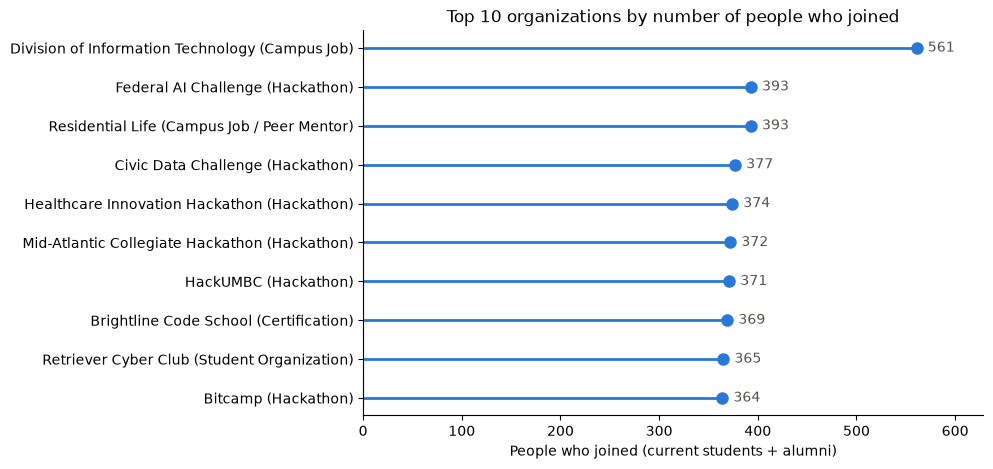

In [8]:
# Chart: top 10 organizations by number of people who joined (current + alumni), lollipop
# clubs and competitive teams all list organization = "UMBC", so use their activity name instead
org = stuExp["organization"].where(stuExp["organization"] != "UMBC", stuExp["experience_name"])
orgPeople = stuExp.groupby(org).agg(people=("campus_id", "nunique"),
                                    kind=("experience_type", lambda s: " / ".join(s.unique())))
top10People = orgPeople.nlargest(10, "people")[::-1]   # reversed so #1 is on top
y = [f"{o} ({k})" for o, k in top10People["kind"].items()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y, 0, top10People["people"], color="#2a78d6", linewidth=2)
ax.scatter(top10People["people"], y, color="#2a78d6", s=64, zorder=3)
for yi, v in zip(y, top10People["people"]):
    ax.annotate(f"{v}", (v, yi), xytext=(8, 0), textcoords="offset points", va="center", color="#52514e")
ax.set(xlim=(0, top10People["people"].max() * 1.12), xlabel="People who joined (current students + alumni)",
       title="Top 10 organizations by number of people who joined")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

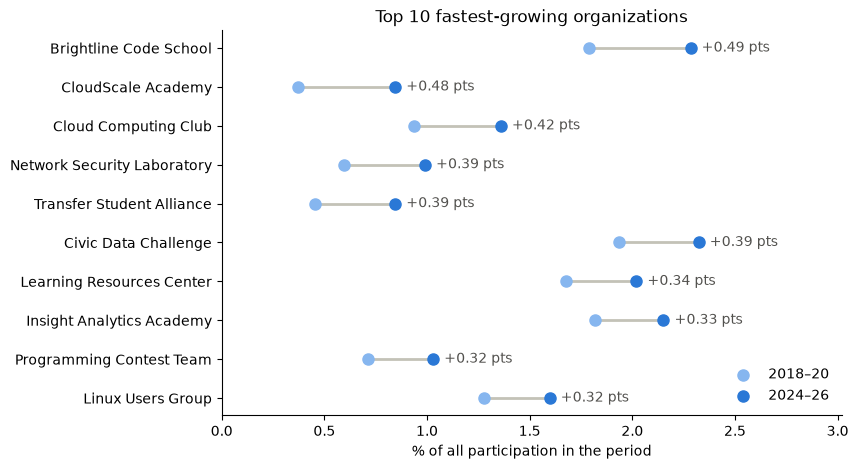

In [9]:
# Chart: top 10 fastest-growing organizations, dumbbell (share of all participation, 2018–20 vs 2024–26)
# share, not raw counts (see the type growth chart); uses `period` from that chart and `org` from the chart above
joins = pd.DataFrame({"org": org, "period": period, "campus_id": stuExp["campus_id"]}).drop_duplicates()
share = pd.crosstab(joins["org"], joins["period"], normalize="columns")[["2018–20", "2024–26"]] * 100
share["change"] = share["2024–26"] - share["2018–20"]
top10Grow = share.nlargest(10, "change")[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(top10Grow.index, top10Grow["2018–20"], top10Grow["2024–26"], color="#c3c2b7", linewidth=2)
ax.scatter(top10Grow["2018–20"], top10Grow.index, color="#86b6ef", s=64, zorder=3, label="2018–20")
ax.scatter(top10Grow["2024–26"], top10Grow.index, color="#2a78d6", s=64, zorder=3, label="2024–26")
for o, r in top10Grow.iterrows():
    ax.annotate(f"+{r['change']:.2f} pts", (r["2024–26"], o), xytext=(8, 0), textcoords="offset points",
                va="center", color="#52514e")
ax.set(xlim=(0, top10Grow["2024–26"].max() * 1.3), xlabel="% of all participation in the period",
       title="Top 10 fastest-growing organizations")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

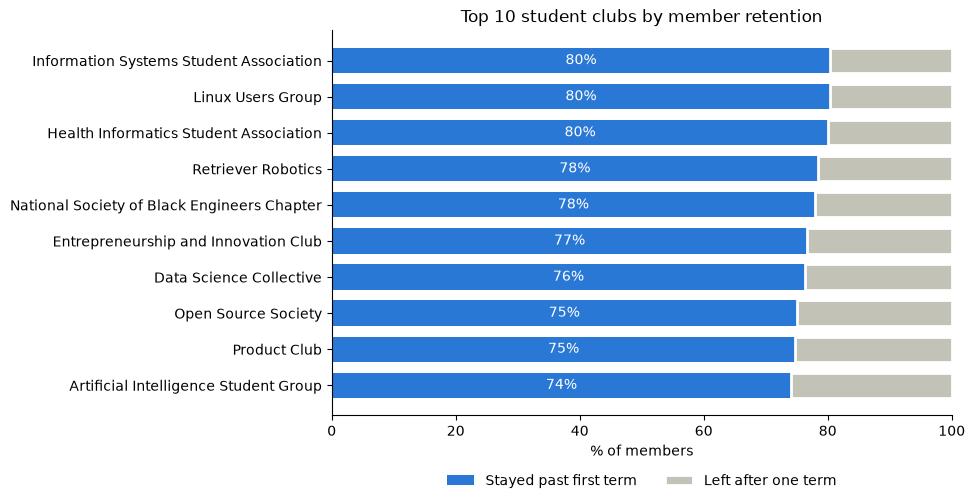

In [10]:
# Chart: top 10 student clubs by retention = % of members who did not leave after one term, 100% stacked bar
# clubs only: interns stay ~90% vs clubs ~75%, so mixing them would rank only companies; "Active" members count as stayed
clubs = stuExp[stuExp["experience_type"] == "Student Organization"]
stayed = (clubs["outcome"] != "Left after one term").groupby(clubs["experience_name"]).mean() * 100
top10Stay = stayed.nlargest(10)[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10Stay.index, top10Stay, color="#2a78d6", height=0.7, label="Stayed past first term")
ax.barh(top10Stay.index, 100 - top10Stay, left=top10Stay, color="#c3c2b7", height=0.7,
        edgecolor="white", linewidth=2, label="Left after one term")
ax.bar_label(ax.containers[0], fmt="%.0f%%", label_type="center", color="white")
ax.set(xlim=(0, 100), xlabel="% of members", title="Top 10 student clubs by member retention")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

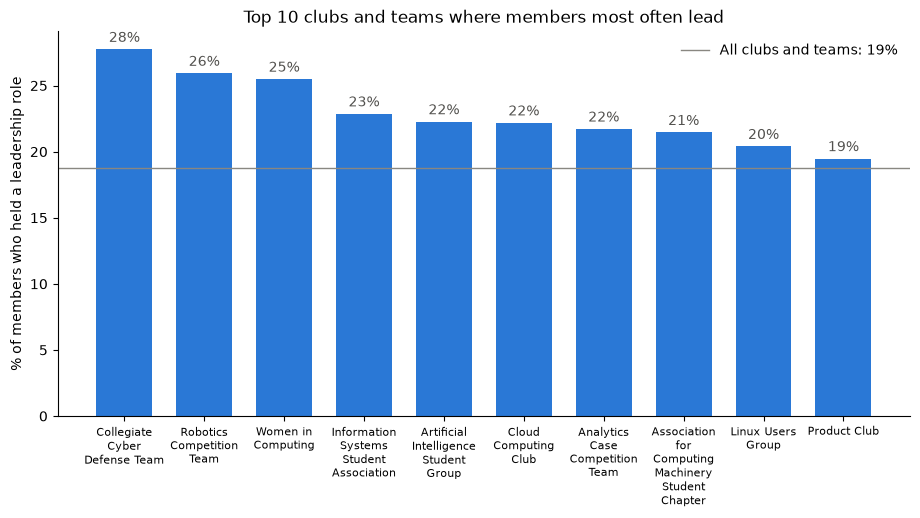

In [11]:
# Chart: top 10 clubs and competitive teams by leadership rate = % of members who became Officer, President or Lead (column chart)
# clubs and teams only (other activity types have no leadership roles); uses `org` from the headcount chart
import textwrap
groups = stuExp["experience_type"].isin(["Student Organization", "Competitive Team"])
isLeader = stuExp.loc[groups, "role_level"].isin(["Officer", "President", "Lead"])
leaderRate = isLeader.groupby(org[groups]).mean() * 100
top10Lead = leaderRate.nlargest(10)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([textwrap.fill(o, 12) for o in top10Lead.index], top10Lead, color="#2a78d6", width=0.7)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color="#52514e")
ax.axhline(isLeader.mean() * 100, color="#898781", linewidth=1, label=f"All clubs and teams: {isLeader.mean():.0%}")
ax.legend(loc="upper right", frameon=False)
ax.tick_params(axis="x", labelsize=8)
ax.set(ylabel="% of members who held a leadership role", title="Top 10 clubs and teams where members most often lead")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

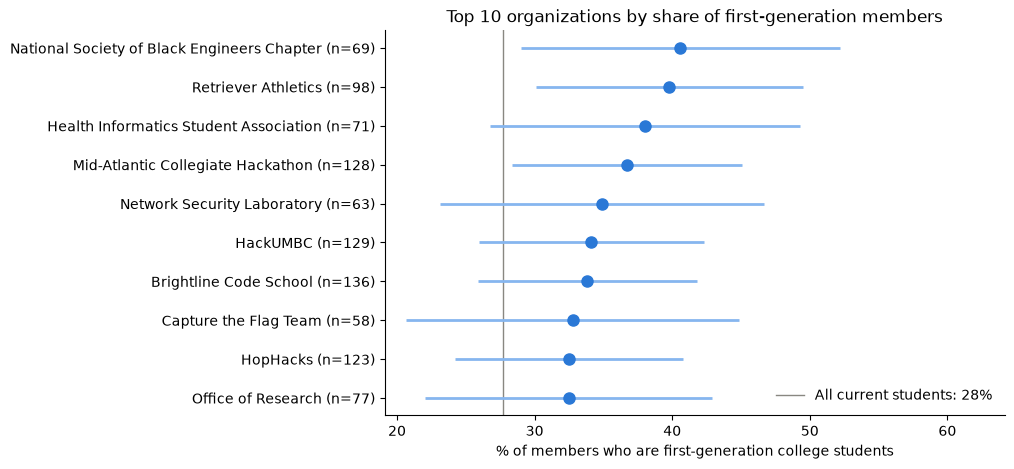

In [12]:
# Chart: top 10 organizations by share of first-generation members, forest plot with 95% confidence intervals
# current students only (is_first_generation exists only there), orgs with >= 50 current members; uses `org` from the headcount chart
# an interval that crosses the gray campus-wide line means that org's difference could be chance
cur = (stuExp.assign(org=org)[stuExp["campus_id"].isin(stuCur["campus_id"])]
       .drop_duplicates(["campus_id", "org"])
       .merge(stuCur[["campus_id", "is_first_generation"]], on="campus_id"))
firstGenRate = cur.groupby("org")["is_first_generation"].agg(pct="mean", members="size")
firstGenRate["pct"] *= 100
top10Gen = firstGenRate[firstGenRate["members"] >= 50].nlargest(10, "pct")[::-1]   # reversed so #1 is on top
ci = 1.96 * np.sqrt(top10Gen["pct"] * (100 - top10Gen["pct"]) / top10Gen["members"])
campusPct = stuCur["is_first_generation"].mean() * 100
y = [f"{o} (n={n})" for o, n in top10Gen["members"].items()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.axvline(campusPct, color="#898781", linewidth=1, label=f"All current students: {campusPct:.0f}%")
ax.errorbar(top10Gen["pct"], y, xerr=ci, fmt="o", color="#2a78d6", ecolor="#86b6ef", elinewidth=2, markersize=8)
ax.set_xlim(right=(top10Gen["pct"] + ci).max() + 12)   # room for the legend
ax.legend(loc="lower right", frameon=False)
ax.set(xlabel="% of members who are first-generation college students",
       title="Top 10 organizations by share of first-generation members")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

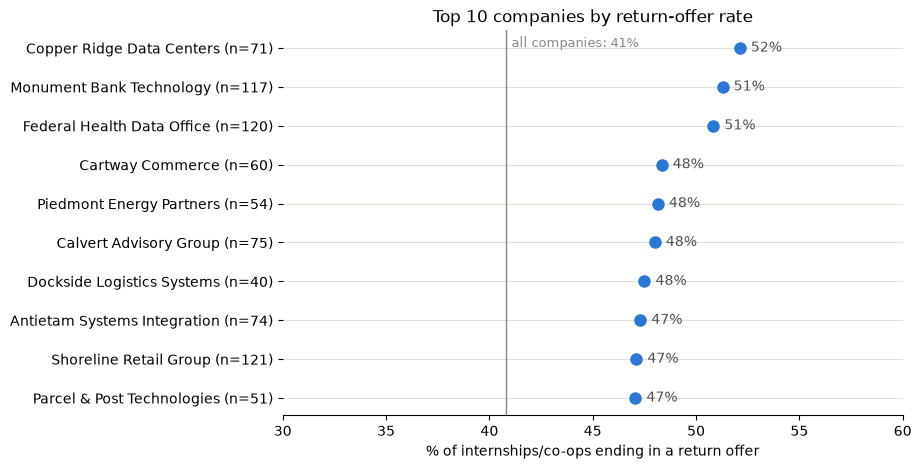

In [13]:
# Chart: top 10 companies by internship/co-op return-offer rate, dot plot (companies with >= 30 records)
# return offer = "Return offer accepted" or "Return offer declined"; "Converted to part-time role" doesn't count
work = stuExp[stuExp["experience_type"].isin(["Internship", "Co-op"])]
gotOffer = work["outcome"].isin(["Return offer accepted", "Return offer declined"])
offerRate = gotOffer.groupby(work["organization"]).agg(["mean", "size"])
top10Offer = offerRate[offerRate["size"] >= 30].nlargest(10, "mean")[::-1]   # reversed so #1 is on top
y = [f"{o} (n={n})" for o, n in top10Offer["size"].items()]
avg = gotOffer.mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.axvline(avg, color="#898781", linewidth=1)
ax.annotate(f"all companies: {avg:.0f}%", (avg, 1), xycoords=("data", "axes fraction"), xytext=(4, -4),
            textcoords="offset points", va="top", color="#898781", fontsize=9)
ax.scatter(top10Offer["mean"] * 100, y, color="#2a78d6", s=64, zorder=3)
for yi, v in zip(y, top10Offer["mean"]):
    ax.annotate(f"{v:.0%}", (v * 100, yi), xytext=(8, 0), textcoords="offset points", va="center", color="#52514e")
ax.set(xlim=(30, 60), xlabel="% of internships/co-ops ending in a return offer",
       title="Top 10 companies by return-offer rate")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

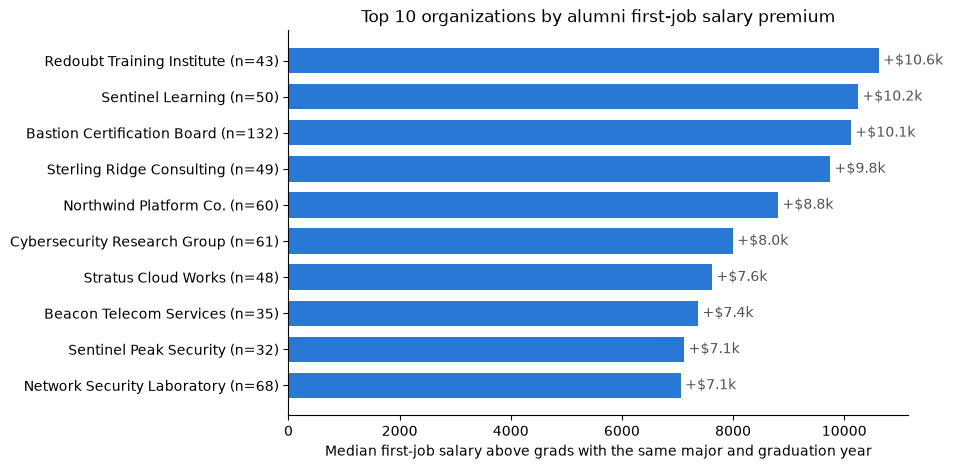

In [14]:
# Chart: top 10 organizations (n >= 30 alumni) by median first-job salary premium
# alumni only; one row per person per organization, so repeat entries don't double-count
# sal_adj = first-job salary minus the median of grads with the same major and graduation year
sal = stuAlum["first_job_annual_salary_usd"]
stuAlum["sal_adj"] = sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")
expAlu = stuExp[stuExp["campus_id"].isin(stuAlum["campus_id"])].drop_duplicates(["campus_id", "organization"])
m = expAlu.merge(stuAlum[["campus_id", "sal_adj"]], on="campus_id")

orgRank = m.groupby("organization").agg(
    n=("sal_adj", "count"),          # alumni with a first-job salary
    premium=("sal_adj", "median"),
)
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "premium")
plotData = top10[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"{o} (n={n})" for o, n in plotData["n"].items()], plotData["premium"], color="#2a78d6", height=0.7)
ax.bar_label(ax.containers[0], labels=[f"+${v/1000:.1f}k" for v in plotData["premium"]], padding=3, color="#52514e")
ax.set(xlabel="Median first-job salary above grads with the same major and graduation year",
       title="Top 10 organizations by alumni first-job salary premium")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

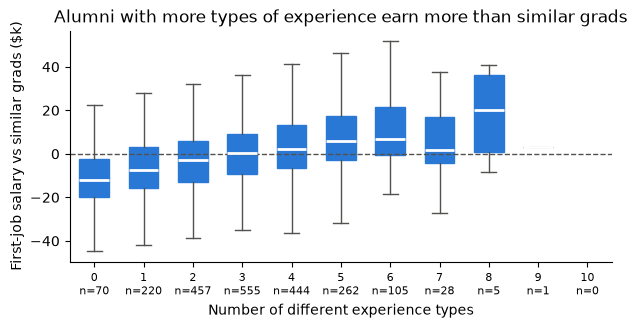

In [15]:
# Chart: box plot of alumni salary premium by number of experience types tried
# alumni only; salary minus the median of grads with the same major and graduation year (fair comparison across majors and years)
sal = stuAlum["first_job_annual_salary_usd"]
adj = (sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")) / 1000
grp = stuAlum["campus_id"].map(breadth)
data = [adj[(grp == k) & adj.notna()] for k in range(11)]
labels = [f"{k}\nn={len(d)}" for k, d in enumerate(data)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot(data, tick_labels=labels, widths=0.6, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#2a78d6", edgecolor="#2a78d6"), medianprops=dict(color="white", linewidth=2),
           whiskerprops=dict(color="#52514e"), capprops=dict(color="#52514e"))
ax.axhline(0, color="#52514e", linestyle="--", linewidth=1)
ax.tick_params(axis="x", labelsize=8)
ax.set(xlabel="Number of different experience types", ylabel="First-job salary vs similar grads ($k)",
       title="Alumni with more types of experience earn more than similar grads")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [16]:
# Data only (no chart): same top-10 salary premium ranking as the top-10 chart above
stuAlum["sal_adj"] = sal - sal.groupby([stuAlum["major"], stuAlum["graduation_year"]]).transform("median")

m = (stuExp.drop_duplicates(["campus_id", "organization"])
           .merge(stuAlum[["campus_id", "sal_adj"]], on="campus_id"))   # inner join = alumni only
orgRank = m.groupby("organization").agg(n=("sal_adj", "count"), premium=("sal_adj", "median"))
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "premium")

In [17]:
# Table: Tiger Data storage: hypertables, chunks and columnstore compression (this section needs TIGER_URL)
# profiles (students_current, alumni, course_catalog) are plain Postgres tables; activity streams are hypertables
assert engine is not None, "The Tiger Data section needs TIGER_URL in .env"
pd.read_sql("""
    SELECT h.hypertable_name AS "table", h.num_chunks AS chunks,
           pg_size_pretty(s.before) AS "row store", pg_size_pretty(s.after) AS columnstore,
           round(100 * (1 - s.after::numeric / s.before))::int AS saved_pct
    FROM timescaledb_information.hypertables h,
         LATERAL (SELECT sum(before_compression_total_bytes)::bigint AS before,
                         sum(after_compression_total_bytes)::bigint AS after
                  FROM chunk_columnstore_stats((h.hypertable_schema || '.' || h.hypertable_name)::regclass)) s
    ORDER BY s.before DESC""", engine)

,table,chunks,row store,columnstore,saved_pct
0,transcripts,5,29 MB,2624 kB,91
1,student_experience,5,5320 kB,904 kB,83
2,employment_history,3,3496 kB,624 kB,82


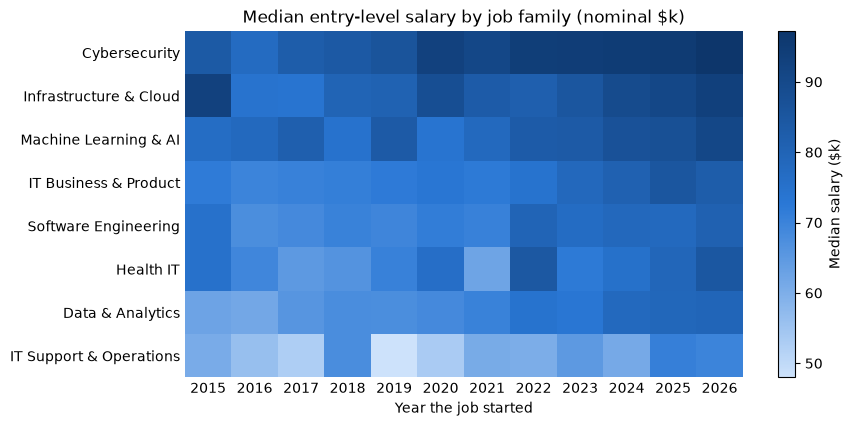

In [18]:
# Chart: median entry-level salary by job family and start year, from the continuous aggregate salary_by_year (heatmap)
# percentile_agg sketches (timescaledb_toolkit) merge with rollup(), so medians come straight from the aggregate
entry = pd.read_sql("""
    SELECT extract(year FROM year)::int AS year, job_family,
           approx_percentile(0.5, rollup(salary_pct)) / 1000 AS median_k
    FROM salary_by_year WHERE seniority_level = 'Entry'
    GROUP BY 1, 2""", engine).pivot(index="job_family", columns="year", values="median_k")
entry = entry.loc[entry.mean(axis=1).sort_values(ascending=False).index]   # highest-paid family on top
blues = matplotlib.colors.LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#2a78d6", "#0d366b"])

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(entry, cmap=blues, aspect="auto")
ax.set(xticks=range(len(entry.columns)), xticklabels=entry.columns, yticks=range(len(entry)), yticklabels=entry.index,
       xlabel="Year the job started", title="Median entry-level salary by job family (nominal $k)")
fig.colorbar(im, ax=ax, label="Median salary ($k)")
ax.tick_params(length=0)
ax.spines[:].set_visible(False)
plt.show()

In [19]:
# Table: benchmark, the same question answered from the raw hypertable vs the continuous aggregate
# server-side execution time from EXPLAIN ANALYZE (median of 5 runs), so network latency doesn't blur the comparison
queries = {
    "raw hypertable: transcripts": """SELECT time_bucket('1 month', term_start) AS term, subject, avg(grade_points) AS avg_grade_points
                                      FROM transcripts GROUP BY 1, 2""",
    "continuous aggregate: grades_by_term": "SELECT term, subject, avg_grade_points FROM grades_by_term",
}

def serverMs(sql, runs=5):
    with engine.connect() as c:
        return np.median([c.execute(text("EXPLAIN (ANALYZE, FORMAT JSON) " + sql)).scalar()[0]["Execution Time"]
                          for _ in range(runs)])

rawRes, aggRes = (pd.read_sql(q, engine).sort_values(["term", "subject"], ignore_index=True) for q in queries.values())
assert np.allclose(rawRes["avg_grade_points"], aggRes["avg_grade_points"], equal_nan=True)   # same answer, pre-computed

bench = pd.DataFrame({"rows returned": [len(rawRes), len(aggRes)],
                      "server time (ms)": [round(serverMs(q), 2) for q in queries.values()]}, index=list(queries))
bench["speed-up"] = (bench["server time (ms)"].iloc[0] / bench["server time (ms)"]).round().astype(int).astype(str) + "x"
bench

,rows returned,server time (ms),speed-up
raw hypertable: transcripts,818,14.29,1x
continuous aggregate: grades_by_term,818,0.20,71x
